# Code Translation: Java <-> C# using CodeBERT

### Objective
To implement and evaluate a neural code translation system using CodeBERT.

### Goals
- Fine-tune a pretrained CodeBERT model on Java <-> C# dataset
- Generate translations for unseen code
- Evaluate using BLEU, ROUGE-L, and Exact Match
- Analyze performance and limitations

### Dataset
- Source: CodeXGLUE Java-C# dataset
- Train: ~10,300
- Valid: ~500
- Test: ~1,000

### Model
- CodeBERT (RoBERTa-based)

In [20]:
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from transformers import AutoTokenizer
from nltk.translate.bleu_score import corpus_bleu
from rouge_score import rouge_scorer

In [ ]:
!python run.py --model_type roberta  --model_name_or_path microsoft/codebert-base  --tokenizer_name microsoft/codebert-base  --output_dir saved_models_baseline  --test_filename data/test.java-cs.txt.java,data/test.java-cs.txt.cs  --do_test  --eval_batch_size 4  --beam_size 3  --max_source_length 256  --max_target_length 256 

04/18/2026 20:55:34 - INFO - __main__ -   Namespace(model_type='roberta', model_name_or_path='microsoft/codebert-base', tokenizer_name='microsoft/codebert-base', output_dir='saved_models_baseline', load_model_path=None, train_filename=None, dev_filename=None, test_filename='data/test.java-cs.txt.java,data/test.java-cs.txt.cs', config_name='', max_source_length=256, max_target_length=256, do_train=False, do_eval=False, do_test=True, do_lower_case=False, no_cuda=False, train_batch_size=8, eval_batch_size=4, gradient_accumulation_steps=1, learning_rate=5e-05, beam_size=10, weight_decay=0.0, adam_epsilon=1e-08, max_grad_norm=1.0, num_train_epochs=3.0, max_steps=-1, eval_steps=-1, train_steps=-1, warmup_steps=0, local_rank=-1, seed=42)
04/18/2026 20:55:34 - WARNING - __main__ -   Process rank: -1, device: cuda, n_gpu: 1, distributed training: False
c:\Users\Mohit Kumar\Downloads\CodeTranslationProject\myenvmt\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_dow

^C


In [ ]:
refs = []
preds = []

with open("data/test.java-cs.txt.java") as f_java, \
     open("data/test.java-cs.txt.cs") as f_cs:

    for i, (src, tgt) in enumerate(zip(f_java, f_cs)):
        if i >= 200:   # keep it small first
            break

        pred = generate(src.strip())

        refs.append([tgt.strip().split()])
        preds.append(pred.split())

In [42]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

def normalize(s):
    return " ".join(s.strip().split())

refs_clean = refs
preds_clean = [normalize(" ".join(p)).split() for p in preds]

smooth = SmoothingFunction().method1
bleu = corpus_bleu(refs_clean, preds_clean, smoothing_function=smooth)

print("Baseline BLEU:", bleu * 100)

Baseline BLEU: 0.06114900096520539


In [26]:
# Paths
DATA_DIR = "data"
OUTPUT_DIR = "saved_models"
MODEL_NAME = "microsoft/codebert-base"

TRAIN_FILES = [f"{DATA_DIR}/train.java-cs.txt.java", f"{DATA_DIR}/train.java-cs.txt.cs"]
VALID_FILES = [f"{DATA_DIR}/valid.java-cs.txt.java", f"{DATA_DIR}/valid.java-cs.txt.cs"]
TEST_FILES  = [f"{DATA_DIR}/test.java-cs.txt.java",  f"{DATA_DIR}/test.java-cs.txt.cs"]

print("Train files:", TRAIN_FILES)
print("Validation files:", VALID_FILES)
print("Test files:", TEST_FILES)

Train files: ['data/train.java-cs.txt.java', 'data/train.java-cs.txt.cs']
Validation files: ['data/valid.java-cs.txt.java', 'data/valid.java-cs.txt.cs']
Test files: ['data/test.java-cs.txt.java', 'data/test.java-cs.txt.cs']


In [27]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded")

Tokenizer loaded


In [28]:
# Read first 5 lines of training files to check
with open(TRAIN_FILES[0], "r", encoding="utf-8") as f_java, \
     open(TRAIN_FILES[1], "r", encoding="utf-8") as f_cs:
    java_lines = [line.strip() for line in f_java.readlines()[:5]]
    cs_lines   = [line.strip() for line in f_cs.readlines()[:5]]

for i, (j, c) in enumerate(zip(java_lines, cs_lines)):
    print(f"--- Example {i+1} ---")
    print("Java:", j)
    print("C#  :", c, "\n")

--- Example 1 ---
Java: public ListSpeechSynthesisTasksResult listSpeechSynthesisTasks(ListSpeechSynthesisTasksRequest request) {request = beforeClientExecution(request);return executeListSpeechSynthesisTasks(request);}
C#  : public virtual ListSpeechSynthesisTasksResponse ListSpeechSynthesisTasks(ListSpeechSynthesisTasksRequest request){var options = new InvokeOptions();options.RequestMarshaller = ListSpeechSynthesisTasksRequestMarshaller.Instance;options.ResponseUnmarshaller = ListSpeechSynthesisTasksResponseUnmarshaller.Instance;return Invoke<ListSpeechSynthesisTasksResponse>(request, options);} 

--- Example 2 ---
Java: public UpdateJourneyStateResult updateJourneyState(UpdateJourneyStateRequest request) {request = beforeClientExecution(request);return executeUpdateJourneyState(request);}
C#  : public virtual UpdateJourneyStateResponse UpdateJourneyState(UpdateJourneyStateRequest request){var options = new InvokeOptions();options.RequestMarshaller = UpdateJourneyStateRequestMarshal

Train: 10295
Valid: 499
Test : 1000


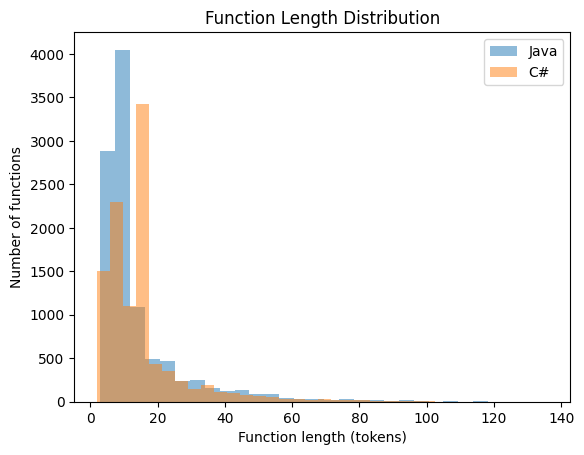

In [29]:
def count_lines(file):
    return sum(1 for _ in open(file, encoding="utf-8"))

print("Train:", count_lines(TRAIN_FILES[0]))
print("Valid:", count_lines(VALID_FILES[0]))
print("Test :", count_lines(TEST_FILES[0]))

def line_lengths(file):
    return [len(line.split()) for line in open(file, encoding="utf-8")]

plt.hist(line_lengths(TRAIN_FILES[0]), bins=30, alpha=0.5, label="Java")
plt.hist(line_lengths(TRAIN_FILES[1]), bins=30, alpha=0.5, label="C#")
plt.xlabel("Function length (tokens)")
plt.ylabel("Number of functions")
plt.title("Function Length Distribution")
plt.legend()
plt.show()

In [ ]:
#fine tuning 
!python run.py --model_type roberta --model_name_or_path microsoft/codebert-base --tokenizer_name microsoft/codebert-base --output_dir saved_models --train_filename data/train.java-cs.txt.java,data/train.java-cs.txt.cs --dev_filename data/valid.java-cs.txt.java,data/valid.java-cs.txt.cs --test_filename data/test.java-cs.txt.java,data/test.java-cs.txt.cs --do_train --do_eval --do_test --train_batch_size 8 --eval_batch_size 8 --train_steps 20000 --eval_steps 2000 --max_source_length 256 --max_target_length 256

In [ ]:
# testing checkpoint-best-ppl
!python run.py --model_type roberta --model_name_or_path microsoft/codebert-base --tokenizer_name microsoft/codebert-base --output_dir saved_models --load_model_path saved_models/checkpoint-best-ppl/pytorch_model.bin --test_filename data/test.java-cs.txt.java,data/test.java-cs.txt.cs --do_test --eval_batch_size 8 --max_source_length 256 --max_target_length 256

In [ ]:
# Bleu score of checkpoint-best-ppl 
# Bleu captures token level precision
with open("saved_models/dev.gold", encoding="utf-8") as f:
    refs = [[line.strip().split()] for line in f]

with open("saved_models/dev.output", encoding="utf-8") as f:
    preds = [line.strip().split() for line in f]

bleu = corpus_bleu(refs, preds)
print("BLEU Score:", bleu * 100)

BLEU Score: 34.59254559590138


In [ ]:
#captures structural similarity
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

refs_text = [" ".join(r[0]) for r in refs]
preds_text = [" ".join(p) for p in preds]

scores = [scorer.score(r, p)['rougeL'].fmeasure for r, p in zip(refs_text, preds_text)]

print("Avg ROUGE-L:", np.mean(scores))

Avg ROUGE-L: 0.6783516134000724


In [32]:
exact_matches = sum([1 for r, p in zip(refs, preds) if r[0] == p])
exact_match_pct = (exact_matches / len(refs)) * 100
print("Exact Match %: {:.10f}".format(exact_match_pct))

Exact Match %: 21.8436873747


In [33]:
for i in range(5):
    print("\n--- Example ---")
    print("Reference:", refs[i])
    print("Prediction:", preds[i])


--- Example ---
Reference: [['public', 'virtual', 'DeleteSubnetGroupResponse', 'DeleteSubnetGroup(DeleteSubnetGroupRequest', 'request){var', 'options', '=', 'new', 'InvokeOptions();options.RequestMarshaller', '=', 'DeleteSubnetGroupRequestMarshaller.Instance;options.ResponseUnmarshaller', '=', 'DeleteSubnetGroupResponseUnmarshaller.Instance;return', 'Invoke<DeleteSubnetGroupResponse>(request,', 'options);}']]
Prediction: ['public', 'virtual', 'DeleteSubnetGroupResponse', 'DeleteSubnetGroup(DeleteSubnetGroupRequest', 'request){var', 'options', '=', 'new', 'InvokeOptions();options.RequestMarshaller', '=', 'DeleteSubnetGroupRequestMarshaller.Instance;options.ResponseUnmarshaller', '=', 'DeleteSubnetGroupResponseUnmarshaller.Instance;return', 'Invoke<DeleteSubnetGroupResponse>(request,', 'options);}']

--- Example ---
Reference: [['public', 'virtual', 'bool', 'Get(string', 'name,', 'bool', 'dflt){bool[]', 'vals;object', 'temp;if', '(valByRound.TryGetValue(name,', 'out', 'temp)', '&&', 'te

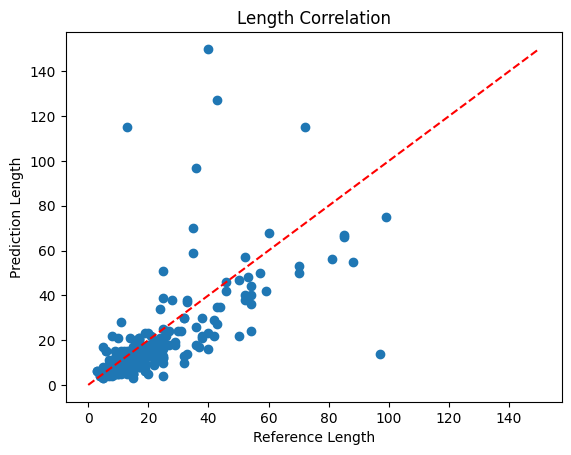

In [34]:
ref_len = [len(r[0]) for r in refs]
pred_len = [len(p) for p in preds]

max_len = max(max(ref_len), max(pred_len))
plt.plot([0, max_len], [0, max_len], 'r--')
plt.scatter(ref_len, pred_len)
plt.xlabel("Reference Length")
plt.ylabel("Prediction Length")
plt.title("Length Correlation")
plt.show()

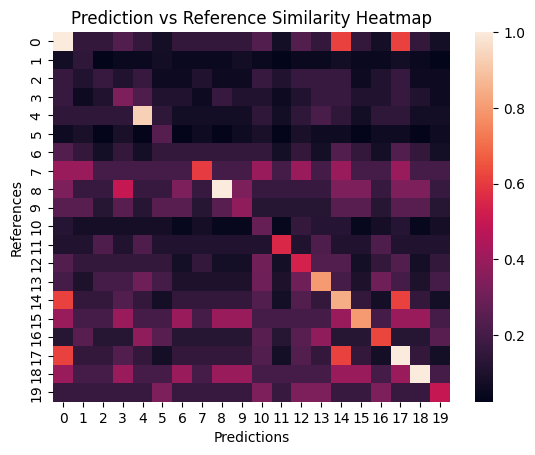

In [35]:
def similarity(a, b):
    return len(set(a.split()) & set(b.split())) / max(len(set(a.split())), 1)

matrix = np.zeros((20, 20))

for i in range(20):
    for j in range(20):
        matrix[i][j] = similarity(refs_text[i], preds_text[j])

sns.heatmap(matrix)
plt.title("Prediction vs Reference Similarity Heatmap")
plt.xlabel("Predictions")
plt.ylabel("References")
plt.show()

In [36]:
#Some Worst Predictions
errors = sorted(
    [(i, scores[i]) for i in range(len(scores))],
    key=lambda x: x[1]
)

for i, score in errors[:5]:
    print("\n--- Worst Case ---")
    print("Score:", score)
    print("REF :", refs_text[i])
    print("PRED:", preds_text[i])


--- Worst Case ---
Score: 0.07142857142857142
REF : public Type PeekNextClass(){if (_nextIndex >= _list.Count){return null;}return _list[_nextIndex].GetType();}
PRED: public virtual java.util.Class.Class.Class.ClassClass.Class.ClassClass.ClassClassClass.Class.Class.Class.Class.Class.Class.Class.Class.Class.Class.Class.Class.Class.Class.Class.Class.Class.Class.Class.Class.Class.NextClass.Class.Class.NextClass.NextClass.NextClass.NextClass.Next(){return this._next;}

--- Worst Case ---
Score: 0.09803921568627451
REF : public static string canonicalizePath(string path, bool discardRelativePrefix){int segmentStart = 0;int deletableSegments = 0;{for (int i = 0; i <= path.Length; ){int nextSegmentStart;if (i == path.Length){nextSegmentStart = i;}else{if (path[i] == '/'){nextSegmentStart = i + 1;}else{i++;continue;}}if (i == segmentStart + 1 && Sharpen.StringHelper.RegionMatches(path, segmentStart, ".", 0, 1)){path = Sharpen.StringHelper.Substring(path, 0, segmentStart) + Sharpen.StringHelpe

#### Observations

- The model learns meaningful structure but struggles with exact syntax.
- BLEU score is moderate due to:
  - Limited dataset size
  - Long sequence truncation
  - Complexity of code translation

#### Conclusion

- CodeBERT performs reasonably well for code translation.
- Evaluation metrics show partial correctness even when exact match is low.
- Further improvements can be achieved with larger datasets and better tuning.